In [24]:
import scanpy as sc
import pandas as pd
import numpy as nu
from scipy.sparse import csr_matrix

from matplotlib import pyplot as plt
from matplotlib import rcParams
%matplotlib inline

##import Spatial Cell ID libraries
#import SpatialCellID as SCID

#for data integration
import scanorama

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=200, facecolor='white')

2023-03-13 12:19:14.953939: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.21.5 scipy==1.7.3 pandas==1.3.5 scikit-learn==1.0.2 statsmodels==0.13.5 python-igraph==0.9.10 pynndescent==0.5.8


In [3]:
adata = sc.read_h5ad("/home/ssarnataro/Work/Camille/python_analysis_from_scratch/adata_adjusted_with_scanorama.h5ad")

In [4]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="cell_ranger", batch_key='sample')

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [5]:
# sc.tl.leiden(adata, key_added="leiden", resolution=0.5)

In [6]:
def bic_score(original_adata, clustering_algorithm='leiden', dim_reduction = 'pca', min_res=0.05, max_res=2.0, step=0.05, plot=True):
    import numpy as nu
    from sklearn.mixture import GaussianMixture
    import scanpy as sc
    import numpy as nu
    sc.settings.verbosity = 0
    
    if dim_reduction == 'pca':
        dim_reduction = 'X_pca'
    elif dim_reduction == 'umap':
        dim_reduction = 'X_umap'
    else:
        print('please choose pca or umap as dimensionality reduction')
        exit
        
    res = list(nu.arange(min_res,max_res,step))
    score = []
    n_clus = []

    for r in res:
        index = res.index(r)
        adata = original_adata.copy()
        string_r = str(r)
        clustering_name = '%s_res%s' %(clustering_algorithm,string_r)
        print('Clustering by using the resolution %.2f, step %i of %i' %(r,index+1,len(res)))
        sc.tl.leiden(adata, key_added="%s_res%s" %(clustering_algorithm,string_r), resolution=r)
        
        n_points = len(adata.obs[clustering_name])
        n_clusters = len(set(adata.obs[clustering_name]))
        n_dimensions = adata.obsm[dim_reduction].shape[1]
        
        n_parameters = (n_clusters - 1) + (n_dimensions * n_clusters) + 1
        
        loglikelihood=0
        for cluster_id in set(adata.obs[clustering_name]):
            cluster_mask = (adata.obs[clustering_name] == cluster_id)
            X_cluster = adata.obsm[dim_reduction][cluster_mask]
            
            n_points_cluster = len(X_cluster)
            centroid = nu.mean(X_cluster, axis=0)
            variance = nu.sum((X_cluster - centroid) ** 2) / (len(X_cluster) - 1)
            loglikelihood += \
              n_points_cluster * nu.log(n_points_cluster) \
              - n_points_cluster * nu.log(n_points) \
              - n_points_cluster * n_dimensions / 2 * nu.log(2 * nu.pi * variance) \
              - (n_points_cluster - 1) / 2

        bic = loglikelihood - (n_parameters / 2) * nu.log(n_points)
        bic = -2*bic
        score.append(bic)
        n_clus.append(n_clusters)
        
        del adata.obs[clustering_name]
        
        
    df = pd.DataFrame()
    df['BIC'] = score
    df['resolution'] = res
    df['n_clus'] = n_clus

    if plot==True:
        df.plot(x='resolution',y='BIC')
    print('\n')

    return df, res[nu.argmin(score)]

In [8]:
# sc.pl.umap(
#     adata,
#     color="leiden",
#     legend_loc="on data",
# )

In [9]:
# clustering_algorithm = 'leiden'

In [10]:
# clustering_name = clustering_algorithm 
# label_name = '1'
# cells_name = adata.obs[clustering_name].loc[adata.obs[clustering_name] == label_name].index
# cells_indices = adata.obs.reset_index().loc[adata.obs.reset_index()['index'].isin(cells_name)].index.values
# coordinates_cluster = adata.X[cells_indices]

Clustering by using the resolution 0.10, step 1 of 9
Clustering by using the resolution 0.20, step 2 of 9
Clustering by using the resolution 0.30, step 3 of 9
Clustering by using the resolution 0.40, step 4 of 9
Clustering by using the resolution 0.50, step 5 of 9
Clustering by using the resolution 0.60, step 6 of 9
Clustering by using the resolution 0.70, step 7 of 9
Clustering by using the resolution 0.80, step 8 of 9
Clustering by using the resolution 0.90, step 9 of 9




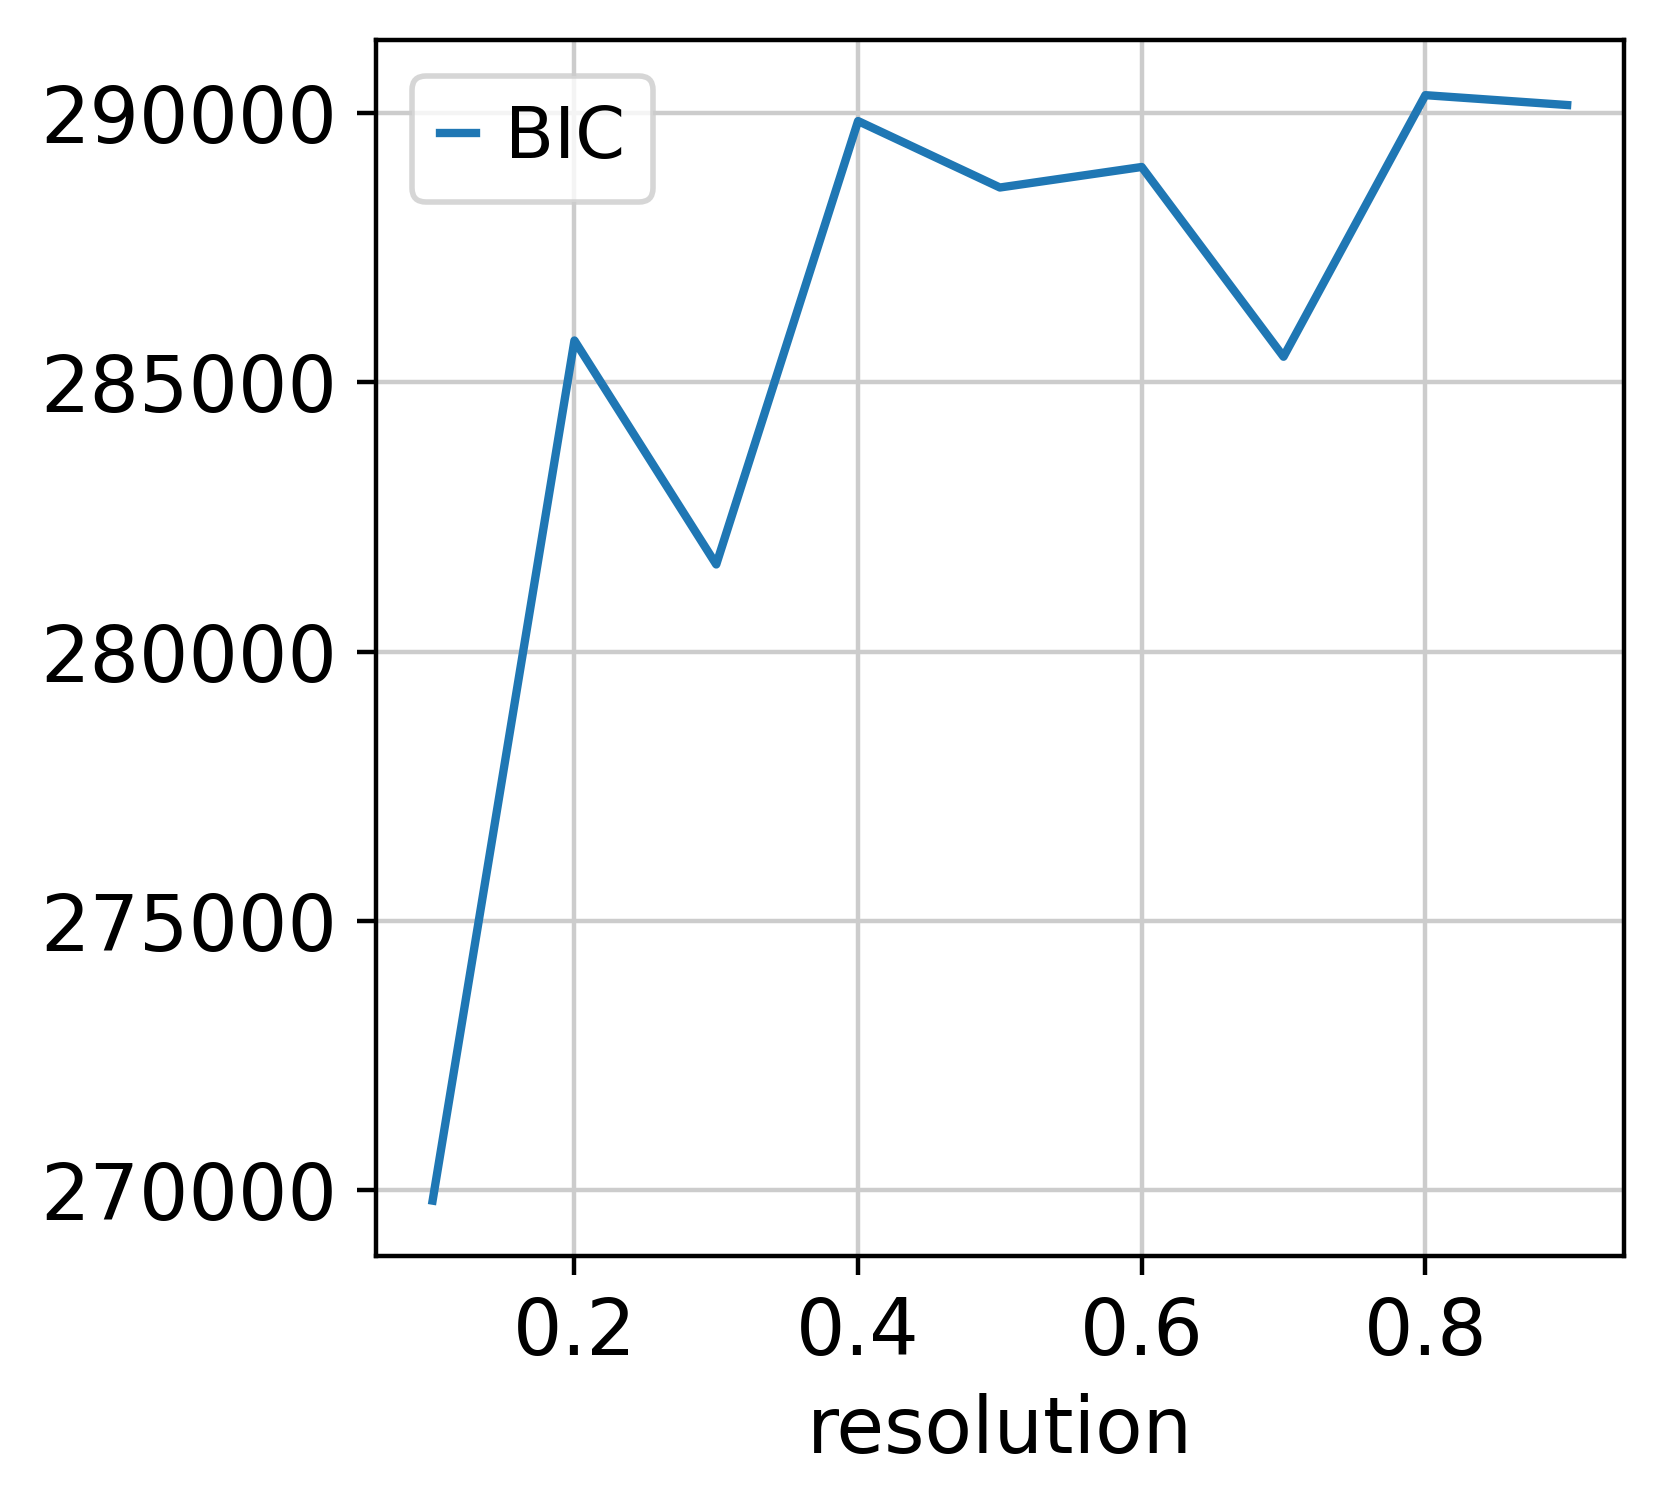

In [7]:
a = bic_score(adata, min_res=0.1,max_res=1.0,step=0.1, plot=True, dim_reduction = 'umap')

In [8]:
a

(             BIC  resolution  n_clus
 0  269807.038424         0.1       2
 1  285774.761895         0.2       7
 2  281616.553594         0.3       8
 3  289848.390041         0.4      10
 4  288614.488884         0.5      12
 5  288995.471062         0.6      15
 6  285472.990759         0.7      17
 7  290328.807327         0.8      18
 8  290145.709763         0.9      21,
 0.1)

Clustering by using the resolution 1.00, step 1 of 10
Clustering by using the resolution 1.10, step 2 of 10
Clustering by using the resolution 1.20, step 3 of 10
Clustering by using the resolution 1.30, step 4 of 10
Clustering by using the resolution 1.40, step 5 of 10
Clustering by using the resolution 1.50, step 6 of 10
Clustering by using the resolution 1.60, step 7 of 10
Clustering by using the resolution 1.70, step 8 of 10
Clustering by using the resolution 1.80, step 9 of 10
Clustering by using the resolution 1.90, step 10 of 10




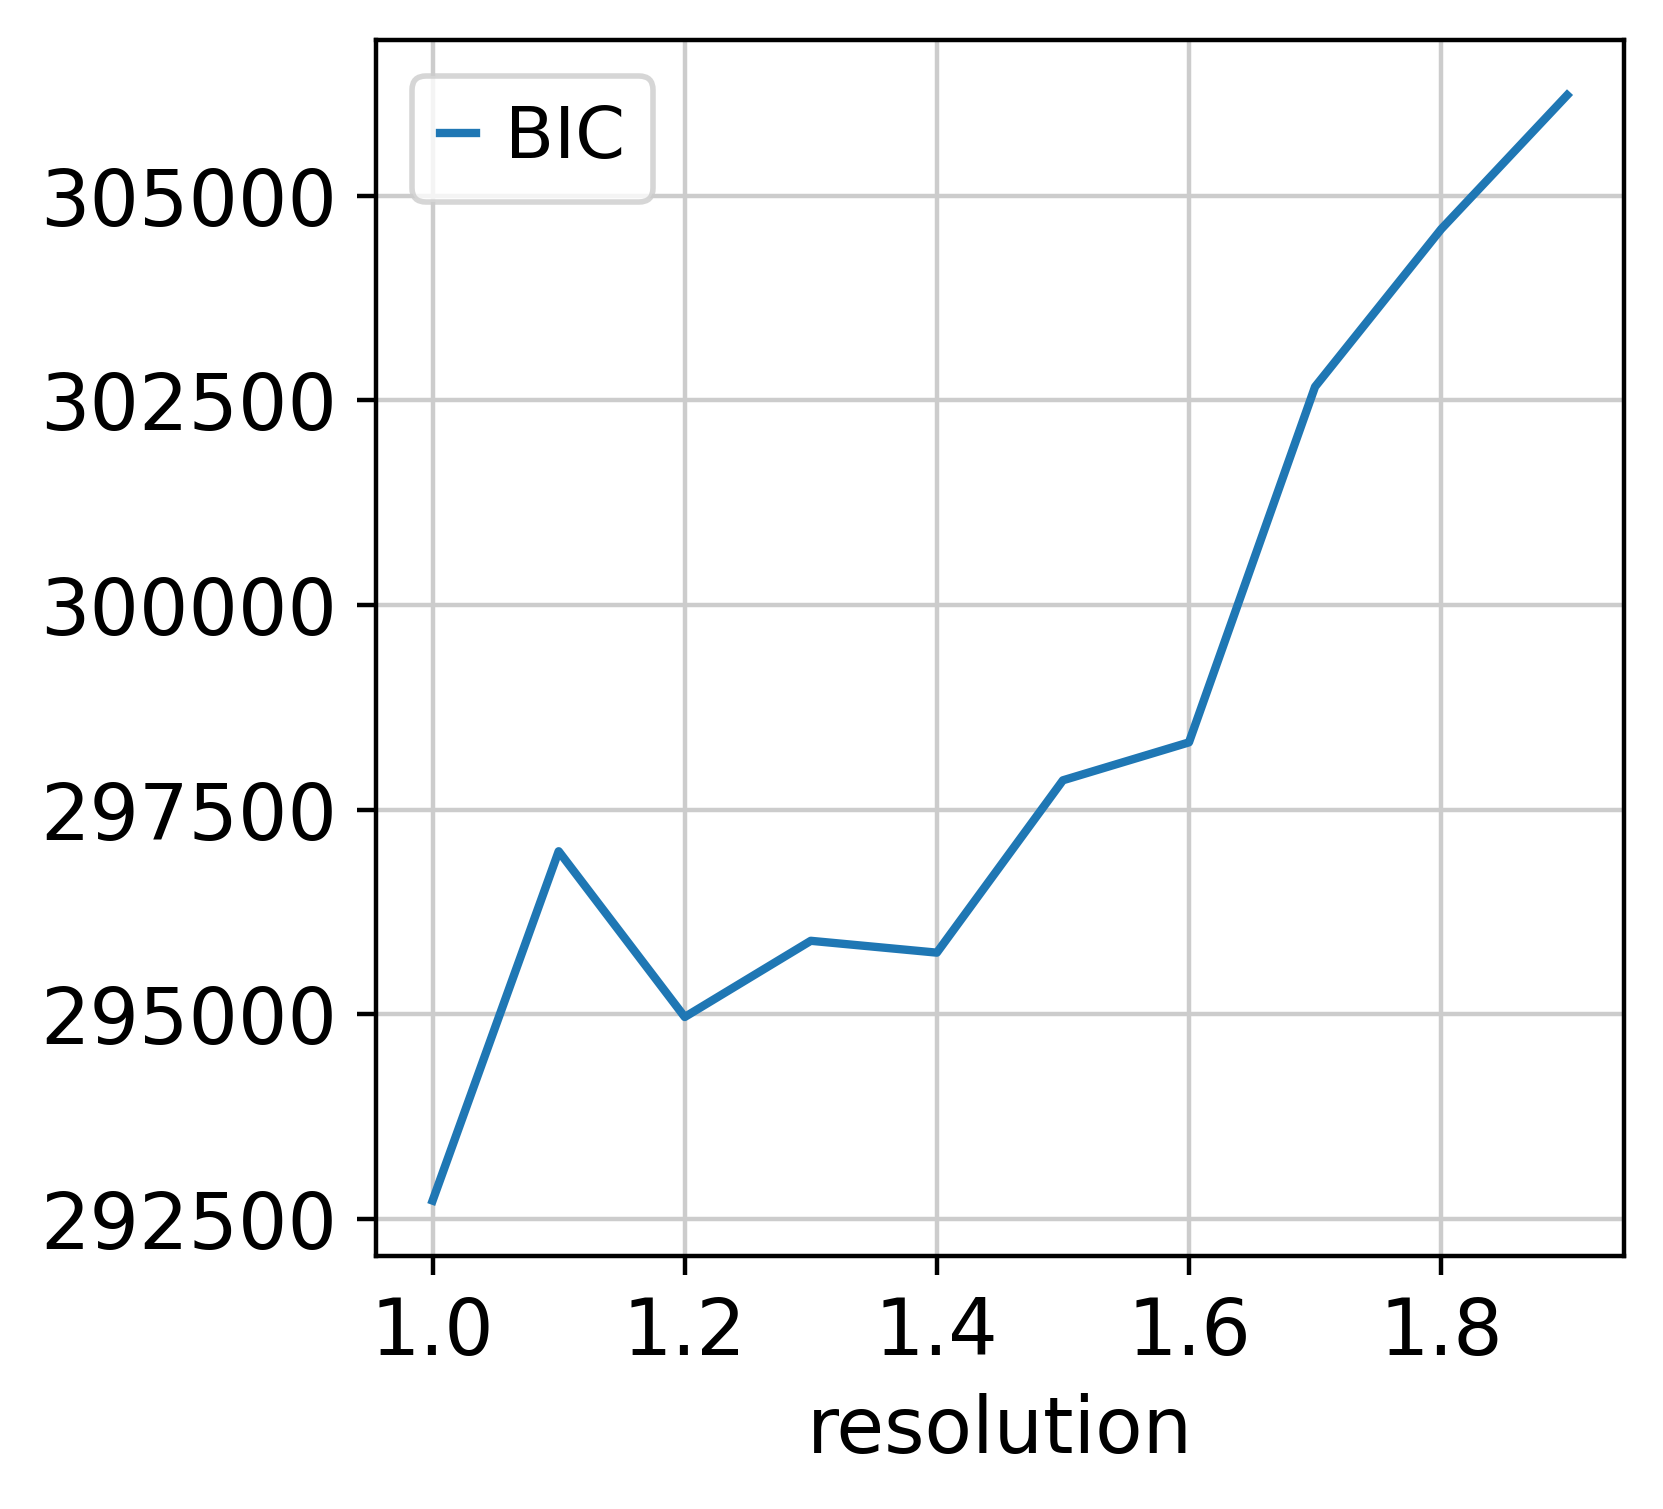

In [9]:
b = bic_score(adata, min_res=1.0,max_res=2.0,step=0.1, plot=True, dim_reduction = 'umap')

In [10]:
b

(             BIC  resolution  n_clus
 0  292723.178293         1.0      22
 1  296991.527207         1.1      23
 2  294966.426350         1.2      23
 3  295897.447057         1.3      23
 4  295752.690329         1.4      24
 5  297858.400165         1.5      27
 6  298321.748702         1.6      28
 7  302666.111125         1.7      29
 8  304591.250611         1.8      32
 9  306229.001097         1.9      33,
 1.0)

In [11]:
a[0].merge(b[0])

,BIC,resolution,n_clus


In [12]:
a[0]

,BIC,resolution,n_clus
0,269807.038424,0.1,2
1,285774.761895,0.2,7
2,281616.553594,0.3,8
3,289848.390041,0.4,10
4,288614.488884,0.5,12
5,288995.471062,0.6,15
6,285472.990759,0.7,17
7,290328.807327,0.8,18
8,290145.709763,0.9,21


In [13]:
b[0]

,BIC,resolution,n_clus
0,292723.178293,1.0,22
1,296991.527207,1.1,23
2,294966.426350,1.2,23
3,295897.447057,1.3,23
4,295752.690329,1.4,24
5,297858.400165,1.5,27
6,298321.748702,1.6,28
7,302666.111125,1.7,29
8,304591.250611,1.8,32
9,306229.001097,1.9,33


In [14]:
a[0].merge(b[0])

,BIC,resolution,n_clus


In [17]:
adata.obsm['Scanorama'].shape

(24118, 100)

In [25]:
a[0].concat(b[0])

AttributeError: 'DataFrame' object has no attribute 'concat'

In [23]:
pandas.concat()

NameError: name 'pandas' is not defined

In [26]:
type(a[0])

pandas.core.frame.DataFrame

In [27]:
A = a[0]
B = b[0]

In [28]:
A.concat(B)

AttributeError: 'DataFrame' object has no attribute 'concat'

In [30]:
C = pd.concat([A,B])

<AxesSubplot:xlabel='resolution'>

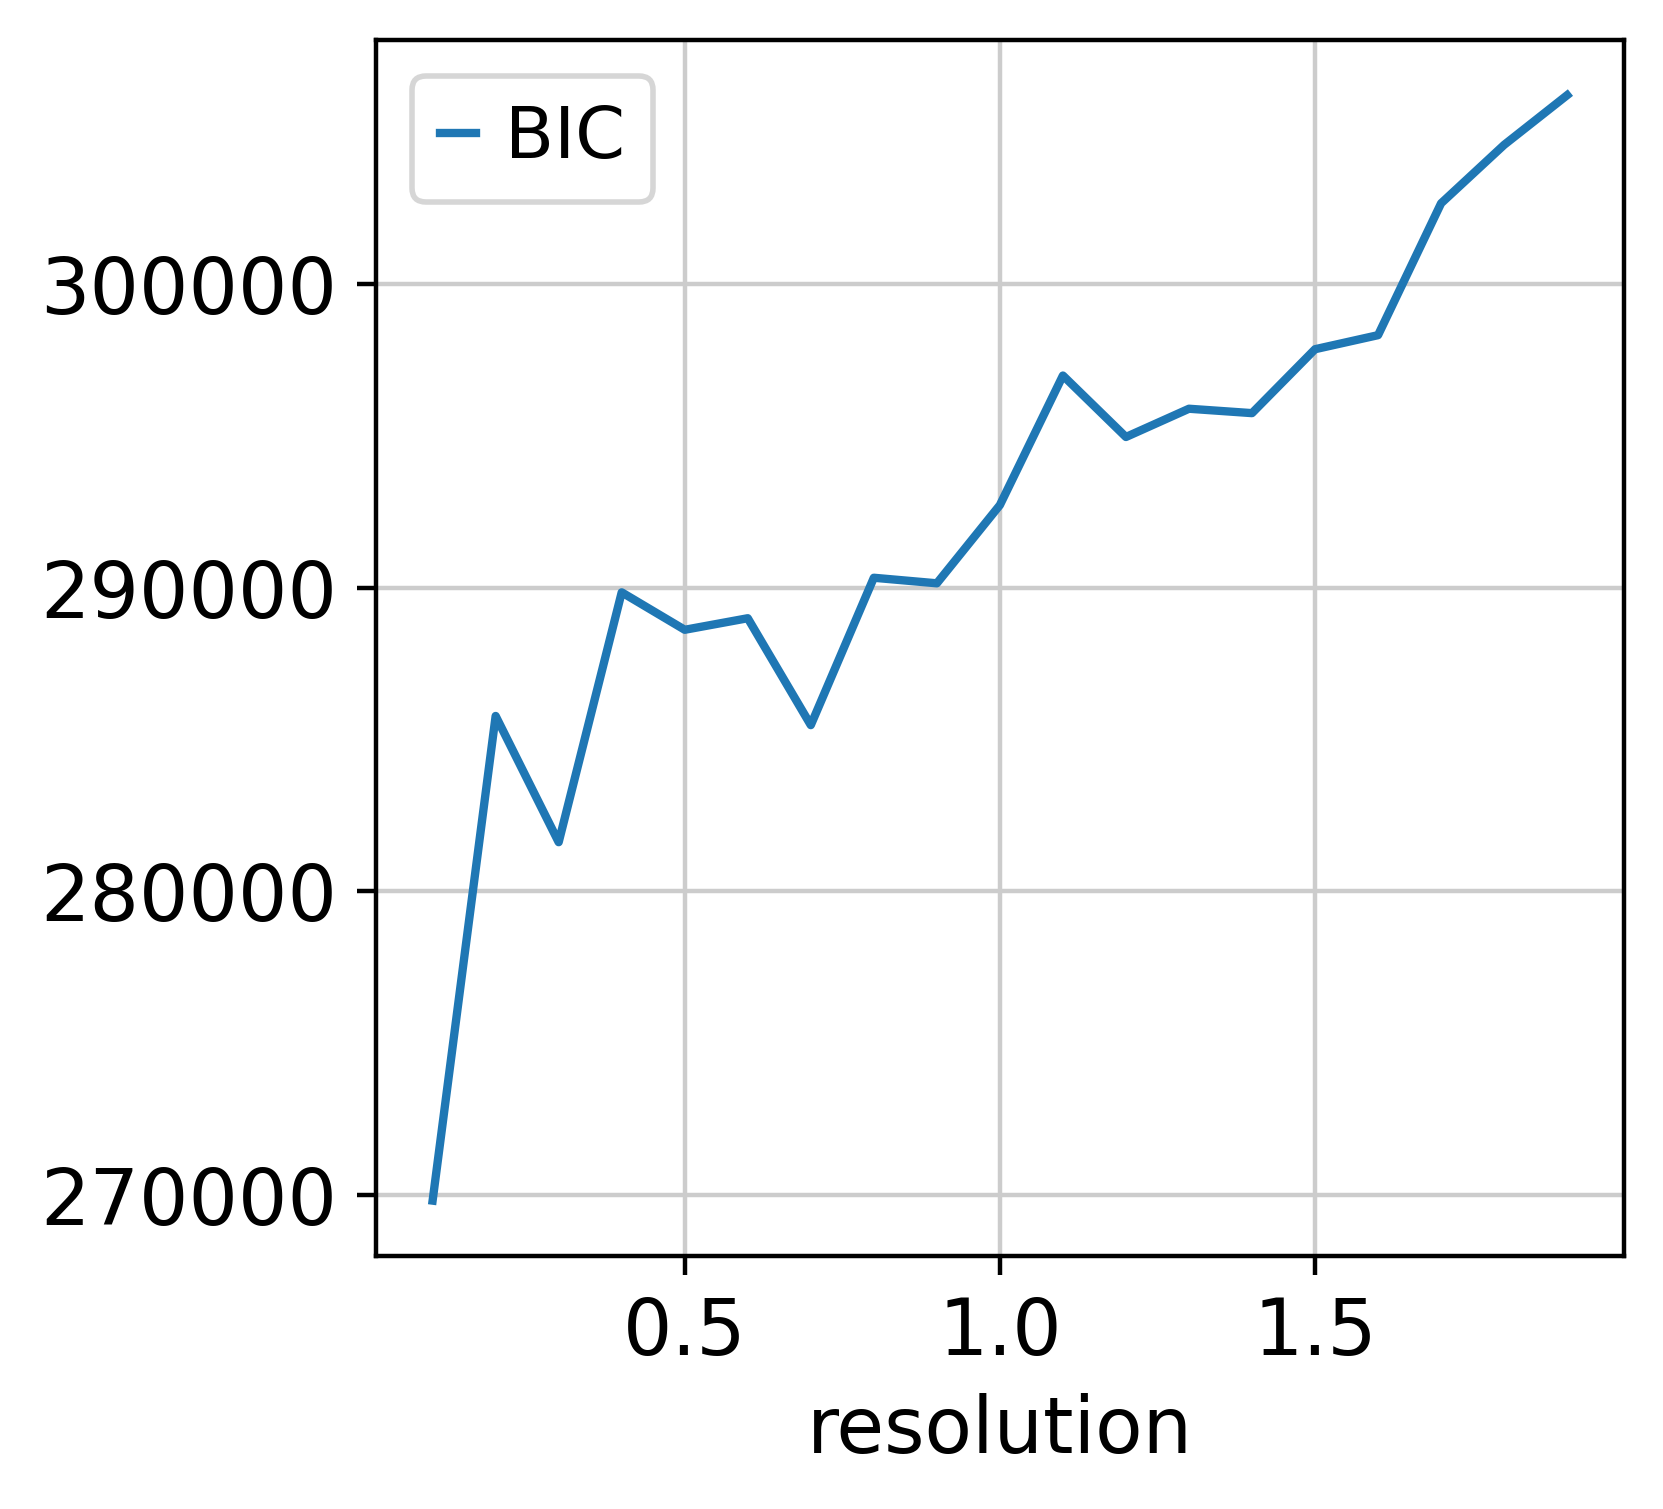

In [31]:
C.plot(x='resolution',y='BIC')